In [23]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision import datasets
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch version:", torch.__version__)

Using device: cuda
Torch version: 2.5.1+cu121


In [24]:
model_name = "facebook/convnext-base-224"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    #use_safetensors=True,
    ignore_mismatched_sizes=True
)

model.to(device)

# 冻结 backbone
for param in model.convnext.parameters():
    param.requires_grad = False

print("Backbone frozen ✅")

d:\conda-envs\dmlap\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /facebook/convnext-base-224/resolve/main/preprocessor_config.json (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))"), '(Request ID: 5ecb6d6c-410d-4f7b-bebc-14bbe63db0b3)')' thrown while requesting HEAD https://huggingface.co/facebook/convnext-base-224/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].
Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_c

Backbone frozen ✅


In [25]:
from torchvision.transforms import RandomHorizontalFlip, RandomRotation

train_transform = Compose([
    Resize((224, 224)),
    RandomHorizontalFlip(),
    RandomRotation(15),
    ToTensor(),
    Normalize(mean=processor.image_mean, std=processor.image_std)
])

val_transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=processor.image_mean, std=processor.image_std)
])

In [26]:
train_dataset = datasets.ImageFolder(
    "dataset/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "dataset/validation",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("Classes:", train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Classes: ['ANI', 'ANT']
Training samples: 66
Validation samples: 22


In [27]:
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-4
)

criterion = torch.nn.CrossEntropyLoss()

In [28]:
scaler = torch.cuda.amp.GradScaler()

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs.logits, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

# 
import os

save_path = os.path.join(os.getcwd(), "model.pth")
torch.save(model.state_dict(), save_path)
print("✅ Model saved at:", save_path)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33908\3378780112.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33908\3378780112.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/15 | Loss: 0.6825 | Train Acc: 0.4394 | Val Acc: 0.4091
Epoch 2/15 | Loss: 0.6719 | Train Acc: 0.6212 | Val Acc: 0.5455
Epoch 3/15 | Loss: 0.6460 | Train Acc: 0.6818 | Val Acc: 0.6364
Epoch 4/15 | Loss: 0.6527 | Train Acc: 0.7121 | Val Acc: 0.6364
Epoch 5/15 | Loss: 0.6122 | Train Acc: 0.7273 | Val Acc: 0.6364
Epoch 6/15 | Loss: 0.6057 | Train Acc: 0.6667 | Val Acc: 0.6364
Epoch 7/15 | Loss: 0.6049 | Train Acc: 0.6970 | Val Acc: 0.6364
Epoch 8/15 | Loss: 0.5956 | Train Acc: 0.6970 | Val Acc: 0.6364
Epoch 9/15 | Loss: 0.5620 | Train Acc: 0.7121 | Val Acc: 0.6364
Epoch 10/15 | Loss: 0.5750 | Train Acc: 0.7576 | Val Acc: 0.6364
Epoch 11/15 | Loss: 0.5736 | Train Acc: 0.7273 | Val Acc: 0.6818
Epoch 12/15 | Loss: 0.5466 | Train Acc: 0.7424 | Val Acc: 0.6818
Epoch 13/15 | Loss: 0.5465 | Train Acc: 0.7273 | Val Acc: 0.7273
Epoch 14/15 | Loss: 0.5557 | Train Acc: 0.7727 | Val Acc: 0.7273
Epoch 15/15 | Loss: 0.5404 | Train Acc: 0.7727 | Val Acc: 0.7273
✅ Model saved at: d:\Abroad study\

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.1632845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7521569..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].


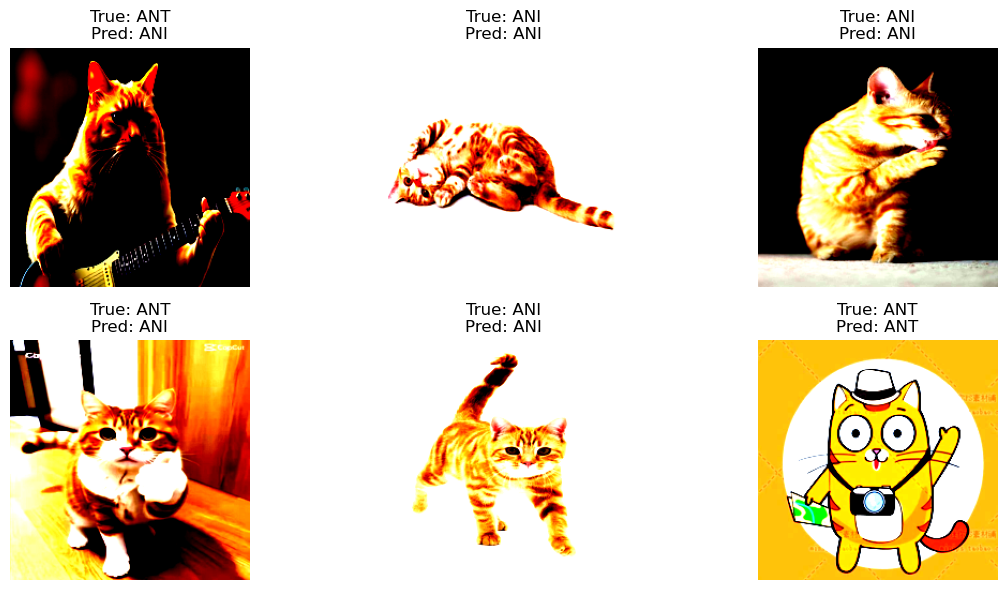

In [29]:
import matplotlib.pyplot as plt
import random

model.eval()

# 随机选 6 张 validation 图片
indices = random.sample(range(len(val_dataset)), 6)

plt.figure(figsize=(12,6))

for i, idx in enumerate(indices):
    img, label = val_dataset[idx]
    
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output.logits, dim=1).item()
    
    plt.subplot(2,3,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"True: {val_dataset.classes[label]}\nPred: {val_dataset.classes[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

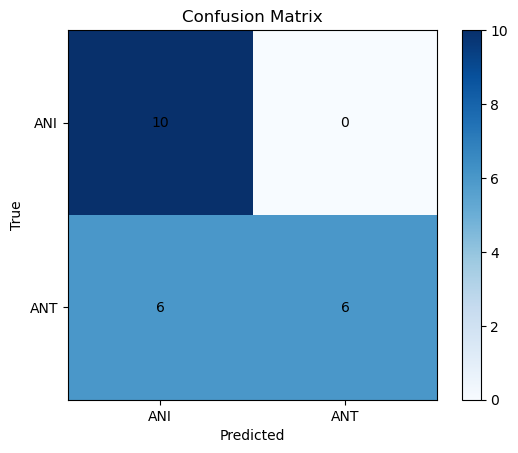

              precision    recall  f1-score   support

         ANI       0.62      1.00      0.77        10
         ANT       1.00      0.50      0.67        12

    accuracy                           0.73        22
   macro avg       0.81      0.75      0.72        22
weighted avg       0.83      0.73      0.71        22



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(2), train_dataset.classes)
plt.yticks(range(2), train_dataset.classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))